In [1]:
import numpy as np
import seaborn as sns
from numpy.polynomial.legendre import leggauss
from matplotlib import pyplot as plt

In [2]:
def exact_p(x):
    return np.sin(np.pi * x)

In [3]:
def exact_u(x):
    return -np.pi * np.cos(np.pi * x)

In [4]:
def exact_f(x):
    return (np.pi**2) * np.sin(np.pi * x)

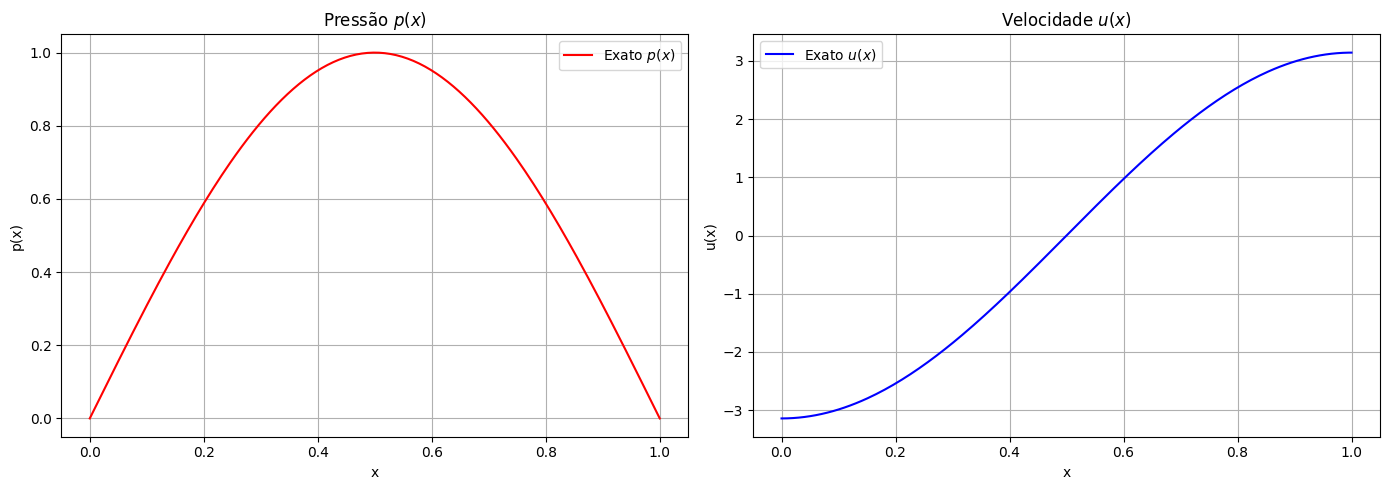

In [5]:
x_exact = np.linspace(0, 1, 200)

plt.figure(figsize=(14, 5))

# Gráfico de p(x)
plt.subplot(1, 2, 1)
plt.plot(x_exact, exact_p(x_exact), '-', label='Exato $p(x)$', color='red')
# plt.plot(nodes, p_approx, 'ro--', label='MEF $p_h(x)$')
plt.title('Pressão $p(x)$')
plt.xlabel('x'); plt.ylabel('p(x)')
plt.legend(); plt.grid(True)

# Gráfico de u(x)
plt.subplot(1, 2, 2)
plt.plot(x_exact, exact_u(x_exact), '-', label='Exato $u(x)$', color='blue')
# plt.plot(nodes, u_approx, 'bs--', label='MEF $u_h(x)$')
plt.title('Velocidade $u(x)$')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig("trabalho1_exatos.pdf")
plt.show()

In [6]:
def create_mesh(l, n_elem):
    nodes = np.linspace(0, l, n_elem+1)
    elements = np.array([[i, i+1] for i in range(n_elem)])

    return nodes, elements

In [7]:
def local_matrices(x1, x2):
    h = x2 - x1
    J = h / 2.0 # Jacobiano da transformação das coordenadas

    # Pontos e pesos da Quadratura de Gauss
    gauss_pts = [-1/np.sqrt(3), 1/np.sqrt(3)]
    weights = [1.0, 1.0]

    K_loc = np.zeros((4, 4))
    F_loc = np.zeros(4)

    for gp, w in zip(gauss_pts, weights):
        # Aqui defino as funções de forma (N) e derivadas (dN/dx) para a aproximação linear
        N = np.array([0.5 * (1 - gp), 0.5*(1+gp)])
        dN_dxi = np.array([-0.5, 0.5])
        dN_dx = dN_dxi/J

        # Aqui faço a operação da coordenada x real no ponto de integração
        x_gp = N[0]*x1 + N[1]*x2
        f_val = exact_f(x_gp)

        for i in range(2):
            for j in range(2):
                idx_u_i, idx_p_i = 2*i, 2*i + 1
                idx_u_j, idx_p_j = 2*j, 2*j + 1

                # Formas bilineares estabilizadas para o item (c)
                K_uu = 0.5 * N[i] * N[j]
                K_up = - N[j] * dN_dx[i] - 0.5 * dN_dx[j]*N[i]
                K_pu = dN_dx[j] * N[i] - 0.5*N[j]*dN_dx[i]
                K_pp = - 0.5*dN_dx[i] * dN_dx[j]

                # Inserção das matrizes na matriz local
                K_loc[idx_u_i, idx_u_j] += K_uu * w * J
                K_loc[idx_u_i, idx_p_j] += K_up * w * J
                K_loc[idx_p_i, idx_u_j] += K_pu * w * J
                K_loc[idx_p_i, idx_p_j] += K_pp * w * J
            # Vetor de forças
            idx_p_i = 2*i + 1
            F_loc[idx_p_i] += f_val*N[i]*w*J

    return K_loc, F_loc

In [8]:
def solve_fem(l, n_elem):
    nodes, elements = create_mesh(l, n_elem)
    n_nodes = len(nodes)
    n_dof = 2 * n_nodes

    K_global = np.zeros((n_dof, n_dof))
    F_global = np.zeros(n_dof)

    for e in elements:
        n1, n2 = e
        x1, x2 = nodes[n1], nodes[n2]
        K_loc, F_loc = local_matrices(x1, x2)

        # Mapeamento do elemento para a matriz global (retirei isso aqui do livro que o Bernardo passou #TODO analisar dps se da certo da outra maneira)
        dofs = [2*n1, 2*n1 + 1, 2*n2, 2*n2 + 1]

        for i in range(4):
            F_global[dofs[i]] += F_loc[i]
            for j in range(4):
                K_global[dofs[i], dofs[j]] += K_loc[i, j]

    # Aqui aplico a condição de contorno de Dirichlet
    fixed_dofs = [1, 2*n_nodes - 1]

    for dof in fixed_dofs:
        K_global[dof, :] = 0.0
        K_global[dof, dof] = 1.0
        F_global[dof] = 0.0

    # print("\tNúmero de condicionamento da matriz de rigidez global com {} elementos: {:.4e}".format(n_elem, np.linalg.cond(K_global)))

    # Resolução do sistema linear global
    U_global = np.linalg.solve(K_global, F_global)

    # Separação dos resultados para as variáveis
    u_app = U_global[0::2]
    p_app = U_global[1::2]

    return nodes, u_app, p_app


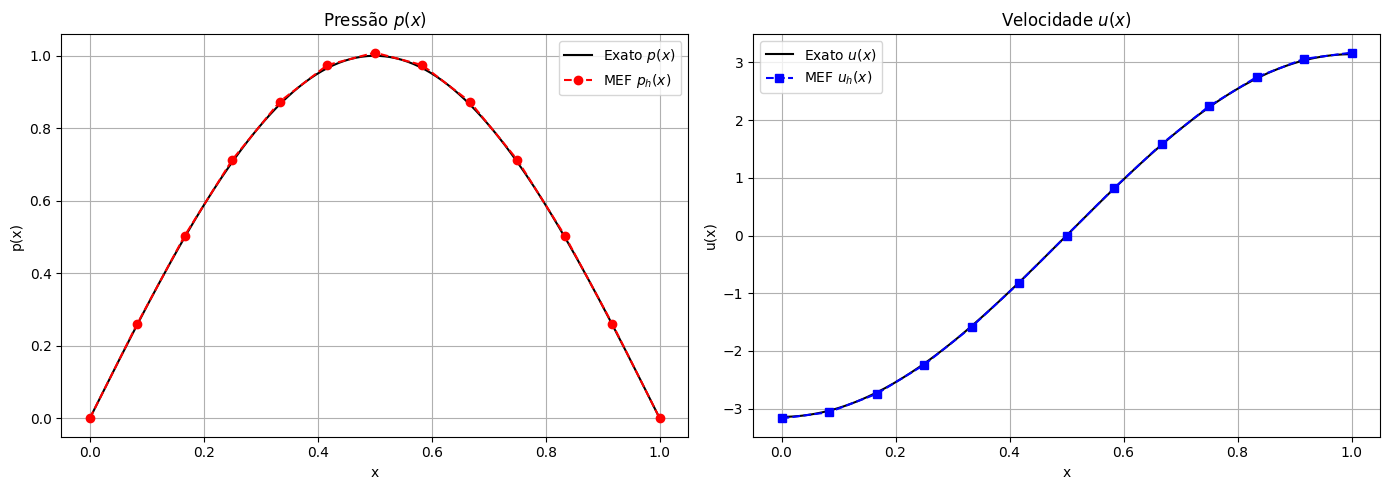

In [9]:
L = 1.0
n_elem = 12
nodes, u_approx, p_approx = solve_fem(L, n_elem)

x_exact = np.linspace(0, L, 200)

plt.figure(figsize=(14, 5))

# Gráfico de p(x)
plt.subplot(1, 2, 1)
plt.plot(x_exact, exact_p(x_exact), 'k-', label='Exato $p(x)$')
plt.plot(nodes, p_approx, 'ro--', label='MEF $p_h(x)$')
plt.title('Pressão $p(x)$')
plt.xlabel('x'); plt.ylabel('p(x)')
plt.legend(); plt.grid(True)

# Gráfico de u(x)
plt.subplot(1, 2, 2)
plt.plot(x_exact, exact_u(x_exact), 'k-', label='Exato $u(x)$')
plt.plot(nodes, u_approx, 'bs--', label='MEF $u_h(x)$')
plt.title('Velocidade $u(x)$')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig("trabalho1_comparacao_d.pdf")
plt.show()


In [10]:
def create_mesh_high_order(l, n_elem, k):
    n_nodes = n_elem*k +1
    nodes = np.linspace(0, l, n_nodes)

    elements = []
    for e in range(n_elem):
        start_ix = e*k
        elem_nodes = [start_ix + i for i in range(k+1)]
        elements.append(elem_nodes)
    return nodes, np.array(elements)

In [11]:
def lagrange_shape(k, xi):
    # Aqui faço N e dN/dxi para um elemento de grau k no ponto xi [-1, 1]
    xi_nodes = np.linspace(-1, 1, k+1)
    N = np.zeros(k + 1)
    dN_dxi = np.zeros(k+1)

    for i in range(k + 1):
        # Aqui calculo o N_i
        p_val = 1.0
        for j in range(k + 1):
            if i!=j:
                p_val *= (xi - xi_nodes[j]) / (xi_nodes[i] - xi_nodes[j])
        N[i] = p_val

        # Aqui calculo dN_i/dxi (usando regra do produto)
        dp_val = 0.0
        for j in range(k +1):
            if i != j:
                term  = 1.0/(xi_nodes[i] - xi_nodes[j])
                for m in range(k+ 1):
                    if m!=i and m!= j:
                        term *= (xi - xi_nodes[m])/(xi_nodes[i] - xi_nodes[m])

                # ADICIONE ESTA LINHA:
                dp_val += term

        dN_dxi[i] = dp_val

    return N, dN_dxi

In [12]:
def solve_fem_high_order(l, n_elem, k):
    nodes, elements = create_mesh_high_order(l, n_elem, k)
    n_nodes = len(nodes)
    n_dof = 2 * n_nodes

    K_global = np.zeros((n_dof, n_dof))
    F_global = np.zeros(n_dof)

    # De acordo com o livro k+2 pontos é o bastante para integrar as matrizes
    # exatamente quando usando Gauss. Então vou fazer isso.
    gauss_pts, weights = leggauss(k + 2)

    for elem_nodes in elements:
        x_coords = nodes[elem_nodes]
        h = x_coords[-1] - x_coords[0]
        J = h / 2.0

        n_loc_nodes = k + 1
        K_loc = np.zeros((2*n_loc_nodes, 2*n_loc_nodes))
        F_loc = np.zeros(2*n_loc_nodes)

        for gp, w in zip(gauss_pts, weights):
            N, dN_dxi = lagrange_shape(k, gp)
            dN_dx = dN_dxi / J
            x_gp = np.dot(N, x_coords)

            f_val = exact_f(x_gp)

            for i in range(n_loc_nodes):
                for j in range(n_loc_nodes):
                    idx_u_i, idx_p_i = 2*i, 2*i+1
                    idx_u_j, idx_p_j = 2*j, 2*j+1

                    K_uu = 0.5 * N[i] * N[j]
                    K_up = -N[j] * dN_dx[i] - 0.5*dN_dx[j]*N[i]
                    K_pu = dN_dx[j] * N[i] - 0.5*N[j]*dN_dx[i]
                    K_pp = -0.5*dN_dx[i]*dN_dx[j]

                    K_loc[idx_u_i, idx_u_j] += K_uu*w*J
                    K_loc[idx_u_i, idx_p_j] += K_up*w*J
                    K_loc[idx_p_i, idx_u_j] += K_pu*w*J
                    K_loc[idx_p_i, idx_p_j] += K_pp*w*J

                idx_p_i = 2*i+1
                F_loc[idx_p_i] += f_val*N[i]*w*J

        dofs = []
        for n in elem_nodes:
            dofs.extend([2*n, 2*n+1])

        for i in range(2*n_loc_nodes):
            F_global[dofs[i]] += F_loc[i]
            for j in range(2*n_loc_nodes):
                K_global[dofs[i], dofs[j]] += K_loc[i, j]

    fixed_dofs = [1, 2*n_nodes-1]
    for dof in fixed_dofs:
        K_global[dof, :] = 0.0
        K_global[dof, dof] = 1.0
        F_global[dof] = 0.0

    U_global = np.linalg.solve(K_global, F_global)
    u_app = U_global[0::2]
    p_app = U_global[1::2]

    # print("\tNúmero de condicionamento da matriz de rigidez global com {} elementos e polinômio de grau {}: {:.4e}".format(n_elem, k, np.linalg.cond(K_global)))


    return nodes, elements, u_app, p_app

In [13]:
def compute_L2_error(L, n_elem, k, nodes, elements, u_approx, p_approx):
    gauss_pts, weights = leggauss(k + 3) # Mais pontos para integrar o erro com exatidão

    error_u_sq = 0.0
    error_p_sq = 0.0

    for elem_nodes in elements:
        x_coords = nodes[elem_nodes]
        u_loc = u_approx[elem_nodes]
        p_loc = p_approx[elem_nodes]

        h = x_coords[-1] - x_coords[0]
        J = h / 2.0

        for gp, w in zip(gauss_pts, weights):
            N, _ = lagrange_shape(k, gp)
            x_gp = np.dot(N, x_coords)

            # Valor do MEF no ponto de Gauss
            u_h_gp = np.dot(N, u_loc)
            p_h_gp = np.dot(N, p_loc)

            # Valor exato no ponto de Gauss
            u_ex_gp = exact_u(x_gp)
            p_ex_gp = exact_p(x_gp)

            error_u_sq += (u_ex_gp - u_h_gp)**2 * w * J
            error_p_sq += (p_ex_gp - p_h_gp)**2 * w * J

    return np.sqrt(error_u_sq), np.sqrt(error_p_sq)

In [14]:
def convergence_study():
    L = 1.0
    k_values = [1, 2, 3, 4]
    mesh_sizes = [4, 8, 16, 32, 64] # Quantidade de elementos

    # Dicionários para armazenar os dados para o plot
    history_h = {k: [] for k in k_values}
    history_err_u = {k: [] for k in k_values}
    history_err_p = {k: [] for k in k_values}

    print("ESTUDO DE CONVERGÊNCIA L2")
    print("-" * 75)
    print(f"{'k':<3} | {'Nelem':<5} | {'h':<8} | {'Erro u':<12} | {'Taxa u':<8} | {'Erro p':<12} | {'Taxa p':<8}")
    print("-" * 75)

    for k in k_values:
        prev_h = None
        prev_err_u = None
        prev_err_p = None

        for n_elem in mesh_sizes:
            nodes, elements, u_approx, p_approx = solve_fem_high_order(L, n_elem, k)
            err_u, err_p = compute_L2_error(L, n_elem, k, nodes, elements, u_approx, p_approx)

            h = L / n_elem
            rate_u = 0.0
            rate_p = 0.0

            if prev_h is not None:
                # Cálculo da taxa: log(E1/E2) / log(h1/h2)
                rate_u = np.log(prev_err_u / err_u) / np.log(prev_h / h)
                rate_p = np.log(prev_err_p / err_p) / np.log(prev_h / h)

            print(f"{k:<3} | {n_elem:<5} | {h:<8.4f} | {err_u:<12.3e} | {rate_u:<8.2f} | {err_p:<12.3e} | {rate_p:<8.2f}")

            # Salvando os dados nas listas
            history_h[k].append(h)
            history_err_u[k].append(err_u)
            history_err_p[k].append(err_p)

            prev_h = h
            prev_err_u = err_u
            prev_err_p = err_p

        print("-" * 75)


    plt.figure(figsize=(14, 6))

    # Marcadores para diferenciar cada grau k no gráfico
    markers = ['o', 's', '^', 'D']

    # Gráfico para a Velocidade (u)
    plt.subplot(1, 2, 1)
    for i, k in enumerate(k_values):
        plt.loglog(history_h[k], history_err_u[k], marker=markers[i], label=f'Grau k={k}')

    plt.title('Convergência L2 - Variável $u$', fontsize=14)
    plt.xlabel('Tamanho do elemento $h$', fontsize=12)
    plt.ylabel('Norma do Erro $L_2$', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend(fontsize=11)

    # Gráfico para a Pressão (p)
    plt.subplot(1, 2, 2)
    for i, k in enumerate(k_values):
        plt.loglog(history_h[k], history_err_p[k], marker=markers[i], label=f'Grau k={k}')

    plt.title('Convergência L2 - Variável $p$', fontsize=14)
    plt.xlabel('Tamanho do elemento $h$', fontsize=12)
    plt.ylabel('Norma do Erro $L_2$', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend(fontsize=11)

    plt.tight_layout()
    plt.savefig("trabalho1_convergencia.pdf")
    plt.show()



ESTUDO DE CONVERGÊNCIA L2
---------------------------------------------------------------------------
k   | Nelem | h        | Erro u       | Taxa u   | Erro p       | Taxa p  
---------------------------------------------------------------------------
1   | 4     | 0.2500   | 8.940e-02    | 0.00     | 2.979e-02    | 0.00    
1   | 8     | 0.1250   | 1.989e-02    | 2.17     | 6.403e-03    | 2.22    
1   | 16    | 0.0625   | 4.833e-03    | 2.04     | 1.543e-03    | 2.05    
1   | 32    | 0.0312   | 1.200e-03    | 2.01     | 3.822e-04    | 2.01    
1   | 64    | 0.0156   | 2.994e-04    | 2.00     | 9.532e-05    | 2.00    
---------------------------------------------------------------------------
2   | 4     | 0.2500   | 1.088e-01    | 0.00     | 5.918e-03    | 0.00    
2   | 8     | 0.1250   | 1.458e-02    | 2.90     | 3.104e-04    | 4.25    
2   | 16    | 0.0625   | 3.292e-03    | 2.15     | 3.258e-05    | 3.25    
2   | 32    | 0.0312   | 8.040e-04    | 2.03     | 3.902e-06    | 3.06 

2   | 64    | 0.0156   | 1.999e-04    | 2.01     | 4.827e-07    | 3.02    
---------------------------------------------------------------------------
3   | 4     | 0.2500   | 2.343e-03    | 0.00     | 1.098e-04    | 0.00    
3   | 8     | 0.1250   | 2.287e-04    | 3.36     | 5.608e-06    | 4.29    
3   | 16    | 0.0625   | 2.691e-05    | 3.09     | 3.341e-07    | 4.07    
3   | 32    | 0.0312   | 3.313e-06    | 3.02     | 2.064e-08    | 4.02    
3   | 64    | 0.0156   | 4.126e-07    | 3.01     | 1.286e-09    | 4.00    
---------------------------------------------------------------------------
4   | 4     | 0.2500   | 2.374e-04    | 0.00     | 5.319e-06    | 0.00    
4   | 8     | 0.1250   | 1.132e-05    | 4.39     | 1.174e-07    | 5.50    
4   | 16    | 0.0625   | 6.674e-07    | 4.08     | 3.387e-09    | 5.11    
4   | 32    | 0.0312   | 4.113e-08    | 4.02     | 1.038e-10    | 5.03    
4   | 64    | 0.0156   | 2.564e-09    | 4.00     | 3.239e-12    | 5.00    
-----------------------

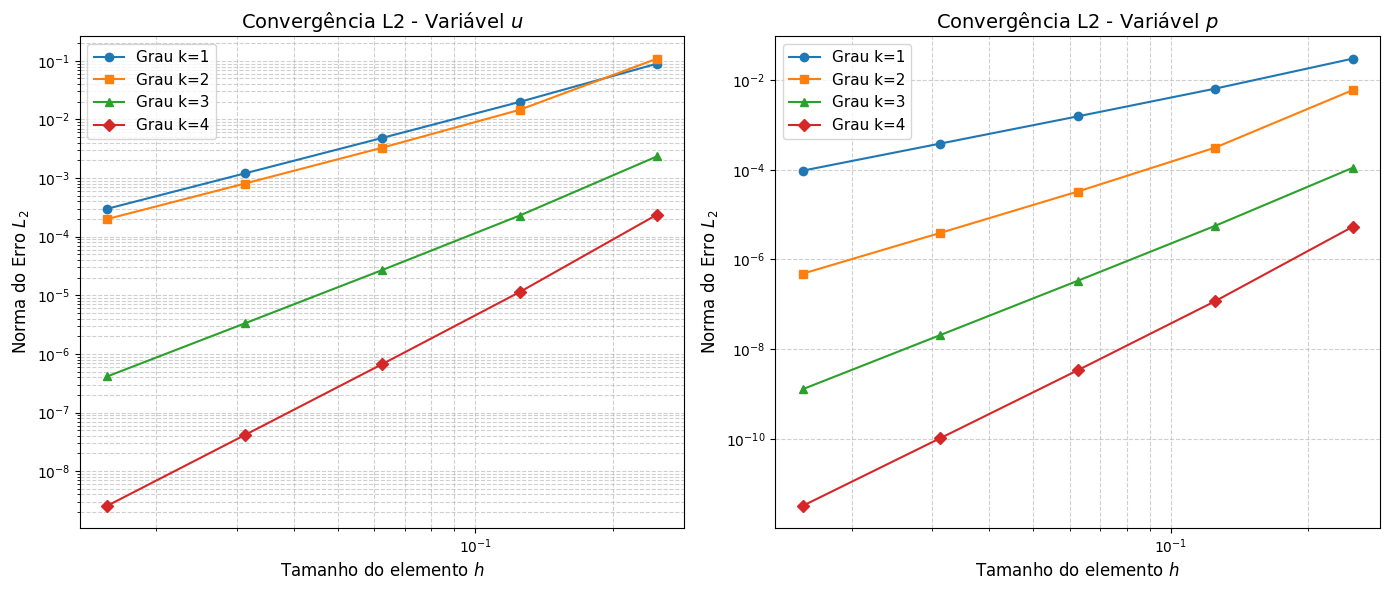

In [15]:
convergence_study()

In [16]:
def solve_fem_high_order_f(l, n_elem, k):
    nodes, elements = create_mesh_high_order(l, n_elem, k)
    n_nodes = len(nodes)
    n_dof = 2 * n_nodes

    K_global = np.zeros((n_dof, n_dof))
    F_global = np.zeros(n_dof)

    # De acordo com o livro k+2 pontos é o bastante para integrar as matrizes
    # exatamente quando usando Gauss. Então vou fazer isso.
    gauss_pts, weights = leggauss(k + 2)

    for elem_nodes in elements:
        x_coords = nodes[elem_nodes]
        h = x_coords[-1] - x_coords[0]
        J = h / 2.0

        n_loc_nodes = k + 1
        K_loc = np.zeros((2*n_loc_nodes, 2*n_loc_nodes))
        F_loc = np.zeros(2*n_loc_nodes)

        for gp, w in zip(gauss_pts, weights):
            N, dN_dxi = lagrange_shape(k, gp)
            dN_dx = dN_dxi / J
            x_gp = np.dot(N, x_coords)

            f_val = exact_f(x_gp)

            for i in range(n_loc_nodes):
                for j in range(n_loc_nodes):
                    idx_u_i, idx_p_i = 2*i, 2*i+1
                    idx_u_j, idx_p_j = 2*j, 2*j+1

                    K_uu = 0.5 * N[i] * N[j] + 0.5 * dN_dx[i] * dN_dx[j]
                    K_up = -N[j] * dN_dx[i] - 0.5*dN_dx[j]*N[i]
                    K_pu = dN_dx[j] * N[i] - 0.5*N[j]*dN_dx[i]
                    K_pp = -0.5*dN_dx[i]*dN_dx[j]

                    K_loc[idx_u_i, idx_u_j] += K_uu*w*J
                    K_loc[idx_u_i, idx_p_j] += K_up*w*J
                    K_loc[idx_p_i, idx_u_j] += K_pu*w*J
                    K_loc[idx_p_i, idx_p_j] += K_pp*w*J

                idx_u_i = 2*i
                idx_p_i = 2*i+1

                F_loc[idx_u_i] += 0.5 * f_val * dN_dx[i] * w * J

                # Termo de força original para p (item c)
                F_loc[idx_p_i] += f_val * N[i] * w * J

        dofs = []
        for n in elem_nodes:
            dofs.extend([2*n, 2*n+1])

        for i in range(2*n_loc_nodes):
            F_global[dofs[i]] += F_loc[i]
            for j in range(2*n_loc_nodes):
                K_global[dofs[i], dofs[j]] += K_loc[i, j]

    fixed_dofs = [1, 2*n_nodes-1]
    for dof in fixed_dofs:
        K_global[dof, :] = 0.0
        K_global[dof, dof] = 1.0
        F_global[dof] = 0.0

    U_global = np.linalg.solve(K_global, F_global)
    u_app = U_global[0::2]
    p_app = U_global[1::2]

    # print("\tNúmero de condicionamento da matriz de rigidez global com {} elementos e polinômio de grau {}: {:.4e}".format(n_elem, k, np.linalg.cond(K_global)))


    return nodes, elements, u_app, p_app

In [17]:
def convergence_study_f():
    L = 1.0
    k_values = [1, 2, 3, 4]
    mesh_sizes = [4, 8, 16, 32, 64] # Quantidade de elementos

    # Dicionários para armazenar os dados para o plot
    history_h = {k: [] for k in k_values}
    history_err_u = {k: [] for k in k_values}
    history_err_p = {k: [] for k in k_values}

    print("ESTUDO DE CONVERGÊNCIA L2")
    print("-" * 75)
    print(f"{'k':<3} | {'Nelem':<5} | {'h':<8} | {'Erro u':<12} | {'Taxa u':<8} | {'Erro p':<12} | {'Taxa p':<8}")
    print("-" * 75)

    for k in k_values:
        prev_h = None
        prev_err_u = None
        prev_err_p = None

        for n_elem in mesh_sizes:
            nodes, elements, u_approx, p_approx = solve_fem_high_order_f(L, n_elem, k)
            err_u, err_p = compute_L2_error(L, n_elem, k, nodes, elements, u_approx, p_approx)

            h = L / n_elem
            rate_u = 0.0
            rate_p = 0.0

            if prev_h is not None:
                # Cálculo da taxa: log(E1/E2) / log(h1/h2)
                rate_u = np.log(prev_err_u / err_u) / np.log(prev_h / h)
                rate_p = np.log(prev_err_p / err_p) / np.log(prev_h / h)

            print(f"{k:<3} | {n_elem:<5} | {h:<8.4f} | {err_u:<12.3e} | {rate_u:<8.2f} | {err_p:<12.3e} | {rate_p:<8.2f}")

            # Salvando os dados nas listas
            history_h[k].append(h)
            history_err_u[k].append(err_u)
            history_err_p[k].append(err_p)

            prev_h = h
            prev_err_u = err_u
            prev_err_p = err_p

        print("-" * 75)


    plt.figure(figsize=(14, 6))

    # Marcadores para diferenciar cada grau k no gráfico
    markers = ['o', 's', '^', 'D']

    # Gráfico para a Velocidade (u)
    plt.subplot(1, 2, 1)
    for i, k in enumerate(k_values):
        plt.loglog(history_h[k], history_err_u[k], marker=markers[i], label=f'Grau k={k}')

    plt.title('Convergência L2 - Variável $u$', fontsize=14)
    plt.xlabel('Tamanho do elemento $h$', fontsize=12)
    plt.ylabel('Norma do Erro $L_2$', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend(fontsize=11)

    # Gráfico para a Pressão (p)
    plt.subplot(1, 2, 2)
    for i, k in enumerate(k_values):
        plt.loglog(history_h[k], history_err_p[k], marker=markers[i], label=f'Grau k={k}')

    plt.title('Convergência L2 - Variável $p$', fontsize=14)
    plt.xlabel('Tamanho do elemento $h$', fontsize=12)
    plt.ylabel('Norma do Erro $L_2$', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend(fontsize=11)

    plt.tight_layout()
    plt.savefig("trabalho1_convergencia_f.pdf")
    plt.show()



ESTUDO DE CONVERGÊNCIA L2
---------------------------------------------------------------------------
k   | Nelem | h        | Erro u       | Taxa u   | Erro p       | Taxa p  
---------------------------------------------------------------------------
1   | 4     | 0.2500   | 1.592e-01    | 0.00     | 1.760e-01    | 0.00    
1   | 8     | 0.1250   | 4.102e-02    | 1.96     | 4.616e-02    | 1.93    
1   | 16    | 0.0625   | 1.033e-02    | 1.99     | 1.168e-02    | 1.98    
1   | 32    | 0.0312   | 2.589e-03    | 2.00     | 2.929e-03    | 2.00    
1   | 64    | 0.0156   | 6.475e-04    | 2.00     | 7.329e-04    | 2.00    
---------------------------------------------------------------------------
2   | 4     | 0.2500   | 6.209e-03    | 0.00     | 2.592e-03    | 0.00    
2   | 8     | 0.1250   | 7.743e-04    | 3.00     | 2.685e-04    | 3.27    
2   | 16    | 0.0625   | 9.672e-05    | 3.00     | 3.151e-05    | 3.09    
2   | 32    | 0.0312   | 1.209e-05    | 3.00     | 3.871e-06    | 3.03 

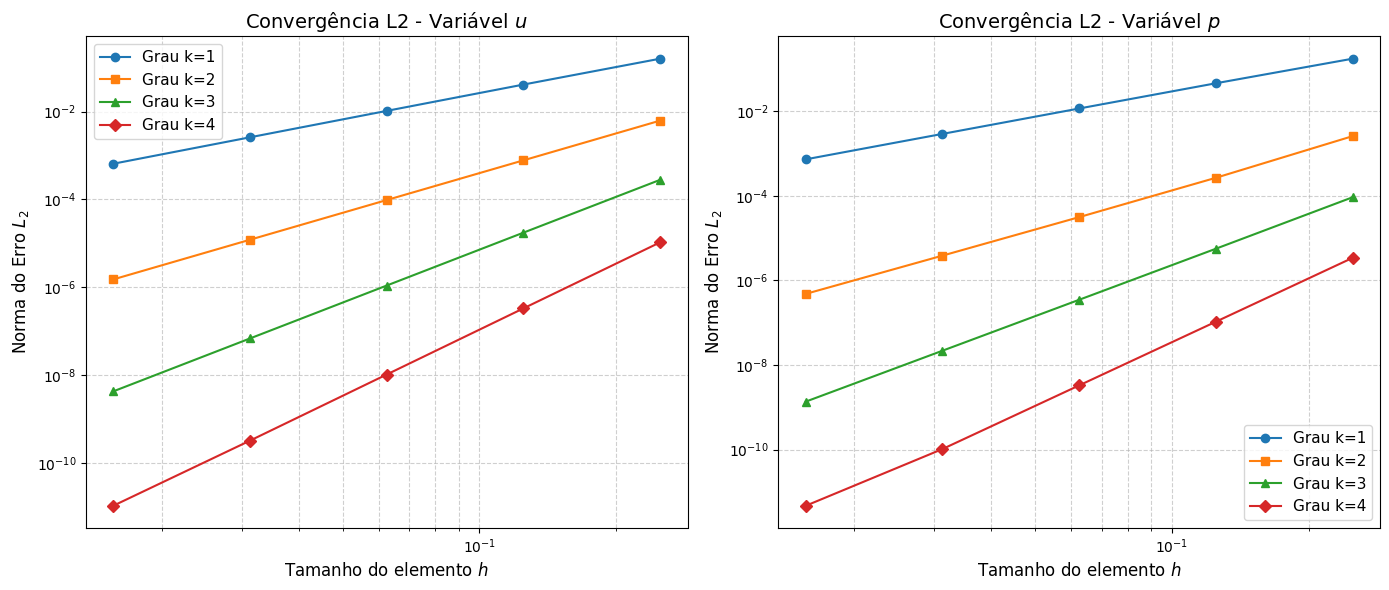

In [18]:
convergence_study_f()

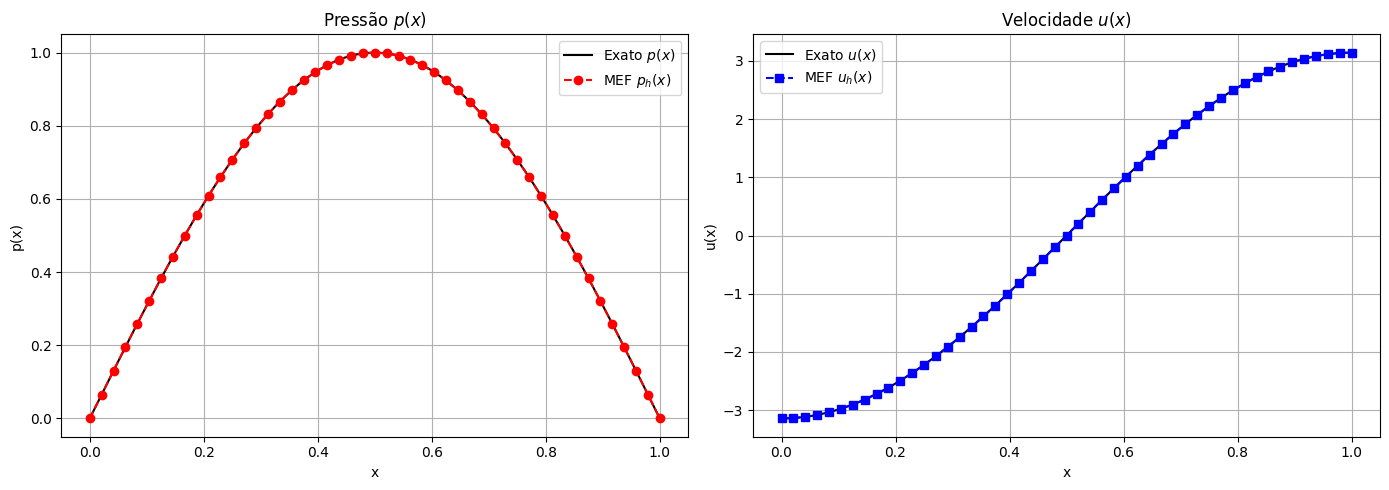

In [19]:
L = 1.0
n_elem = 12
k = 4
nodes, elements, u_approx, p_approx = solve_fem_high_order(L, n_elem, k)

x_exact = np.linspace(0, L, 200)

plt.figure(figsize=(14, 5))

# Gráfico de p(x)
plt.subplot(1, 2, 1)
plt.plot(x_exact, exact_p(x_exact), 'k-', label='Exato $p(x)$')
plt.plot(nodes, p_approx, 'ro--', label='MEF $p_h(x)$')
plt.title('Pressão $p(x)$')
plt.xlabel('x'); plt.ylabel('p(x)')
plt.legend(); plt.grid(True)

# Gráfico de u(x)
plt.subplot(1, 2, 2)
plt.plot(x_exact, exact_u(x_exact), 'k-', label='Exato $u(x)$')
plt.plot(nodes, u_approx, 'bs--', label='MEF $u_h(x)$')
plt.title('Velocidade $u(x)$')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

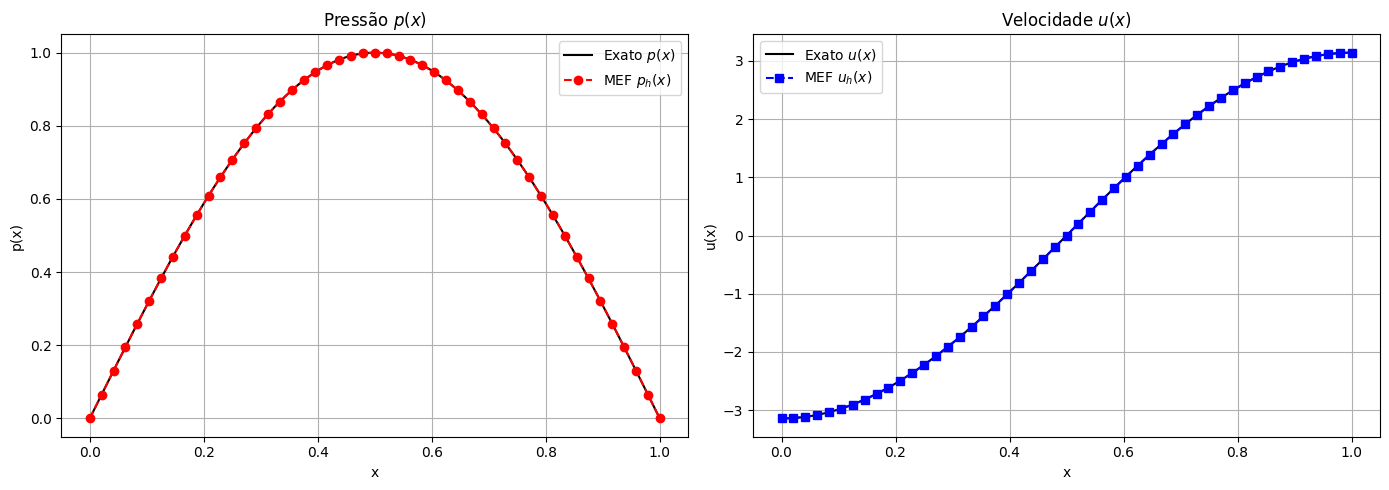

In [20]:
L = 1.0
n_elem = 12
k = 4
nodes, elements, u_approx, p_approx = solve_fem_high_order_f(L, n_elem, k)

x_exact = np.linspace(0, L, 200)

plt.figure(figsize=(14, 5))

# Gráfico de p(x)
plt.subplot(1, 2, 1)
plt.plot(x_exact, exact_p(x_exact), 'k-', label='Exato $p(x)$')
plt.plot(nodes, p_approx, 'ro--', label='MEF $p_h(x)$')
plt.title('Pressão $p(x)$')
plt.xlabel('x'); plt.ylabel('p(x)')
plt.legend(); plt.grid(True)

# Gráfico de u(x)
plt.subplot(1, 2, 2)
plt.plot(x_exact, exact_u(x_exact), 'k-', label='Exato $u(x)$')
plt.plot(nodes, u_approx, 'bs--', label='MEF $u_h(x)$')
plt.title('Velocidade $u(x)$')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
def solve_fem_high_order_no_est(l, n_elem, k):
    nodes, elements = create_mesh_high_order(l, n_elem, k)
    n_nodes = len(nodes)
    n_dof = 2 * n_nodes

    K_global = np.zeros((n_dof, n_dof))
    F_global = np.zeros(n_dof)

    gauss_pts, weights = leggauss(k + 2)

    for elem_nodes in elements:
        x_coords = nodes[elem_nodes]
        h = x_coords[-1] - x_coords[0]
        J = h / 2.0

        n_loc_nodes = k + 1
        K_loc = np.zeros((2*n_loc_nodes, 2*n_loc_nodes))
        F_loc = np.zeros(2*n_loc_nodes)

        for gp, w in zip(gauss_pts, weights):
            N, dN_dxi = lagrange_shape(k, gp)
            dN_dx = dN_dxi / J
            x_gp = np.dot(N, x_coords)

            f_val = exact_f(x_gp)

            for i in range(n_loc_nodes):
                for j in range(n_loc_nodes):
                    idx_u_i, idx_p_i = 2*i, 2*i+1
                    idx_u_j, idx_p_j = 2*j, 2*j+1

                    # ======================================================
                    # MODIFICAÇÃO DO ITEM (g):
                    # Formulação Mista Clássica (Galerkin Padrão sem GLS)
                    # ======================================================
                    K_uu = N[i] * N[j]
                    K_up = -N[j] * dN_dx[i]
                    K_pu = dN_dx[j] * N[i]
                    K_pp = 0.0 # Sem estabilização, esse bloco é zero!

                    K_loc[idx_u_i, idx_u_j] += K_uu*w*J
                    K_loc[idx_u_i, idx_p_j] += K_up*w*J
                    K_loc[idx_p_i, idx_u_j] += K_pu*w*J
                    K_loc[idx_p_i, idx_p_j] += K_pp*w*J

                idx_u_i = 2*i
                idx_p_i = 2*i+1

                # ======================================================
                # MODIFICAÇÃO DO ITEM (g):
                # O vetor de forças só possui o termo do resíduo de p
                # ======================================================
                F_loc[idx_p_i] += f_val * N[i] * w * J

        dofs = []
        for n in elem_nodes:
            dofs.extend([2*n, 2*n+1])

        for i in range(2*n_loc_nodes):
            F_global[dofs[i]] += F_loc[i]
            for j in range(2*n_loc_nodes):
                K_global[dofs[i], dofs[j]] += K_loc[i, j]

    fixed_dofs = [1, 2*n_nodes-1]
    for dof in fixed_dofs:
        K_global[dof, :] = 0.0
        K_global[dof, dof] = 1.0
        F_global[dof] = 0.0

    U_global = np.linalg.solve(K_global, F_global)
    u_app = U_global[0::2]
    p_app = U_global[1::2]

    if(k == 1 and n_elem < 20):
        print(K_global)

    # print("\tNúmero de condicionamento da matriz de rigidez global com {} elementos e polinômio de grau {}: {:.4e}".format(n_elem, k, np.linalg.cond(K_global)))

    return nodes, elements, u_app, p_app

In [22]:
L = 1.0
n_elem = 5
k = 1
nodes, elements, u_approx, p_approx = solve_fem_high_order_no_est(L, n_elem, k)

[[ 6.66666667e-02  5.00000000e-01  3.33333333e-02  5.00000000e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 3.33333333e-02 -5.00000000e-01  1.33333333e-01  0.00000000e+00
   3.33333333e-02  5.00000000e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-5.00000000e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   5.00000000e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  3.33333333e-02 -5.00000000e-01
   1.33333333e-01  0.00000000e+00  3.33333333e-02  5.00000000e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.

[[ 2.77777778e-02  5.00000000e-01  1.38888889e-02  5.00000000e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.38888889e-02 -5.00000000e-01  5.55555556e-02  0.00000000e+00
   1.38888889e-02  5.00000000e-01  0.00000000e+00  0.00000000e+00
   0.0

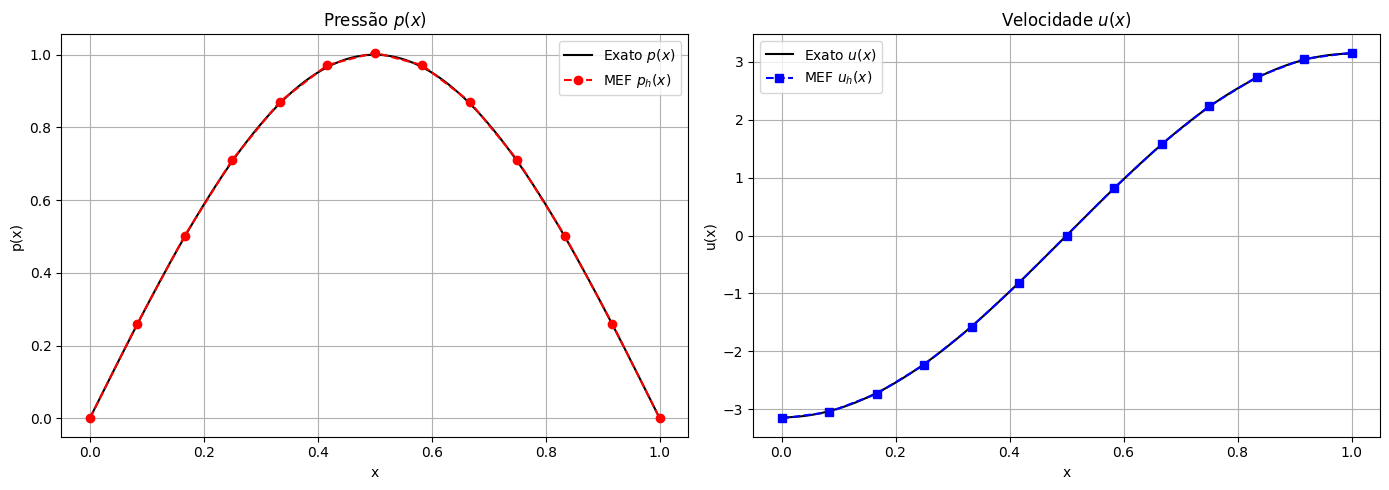

In [23]:
L = 1.0
n_elem = 12
k = 1
nodes, elements, u_approx, p_approx = solve_fem_high_order_no_est(L, n_elem, k)

x_exact = np.linspace(0, L, 200)

plt.figure(figsize=(14, 5))

# Gráfico de p(x)
plt.subplot(1, 2, 1)
plt.plot(x_exact, exact_p(x_exact), 'k-', label='Exato $p(x)$')
plt.plot(nodes, p_approx, 'ro--', label='MEF $p_h(x)$')
plt.title('Pressão $p(x)$')
plt.xlabel('x'); plt.ylabel('p(x)')
plt.legend(); plt.grid(True)

# Gráfico de u(x)
plt.subplot(1, 2, 2)
plt.plot(x_exact, exact_u(x_exact), 'k-', label='Exato $u(x)$')
plt.plot(nodes, u_approx, 'bs--', label='MEF $u_h(x)$')
plt.title('Velocidade $u(x)$')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

In [24]:
def convergence_study_g():
    L = 1.0
    k_values = [1, 2, 3, 4]
    mesh_sizes = [4, 8, 16, 32, 64] # Quantidade de elementos

    # Dicionários para armazenar os dados para o plot
    history_h = {k: [] for k in k_values}
    history_err_u = {k: [] for k in k_values}
    history_err_p = {k: [] for k in k_values}

    print("ESTUDO DE CONVERGÊNCIA L2")
    print("-" * 75)
    print(f"{'k':<3} | {'Nelem':<5} | {'h':<8} | {'Erro u':<12} | {'Taxa u':<8} | {'Erro p':<12} | {'Taxa p':<8}")
    print("-" * 75)

    for k in k_values:
        prev_h = None
        prev_err_u = None
        prev_err_p = None

        for n_elem in mesh_sizes:
            nodes, elements, u_approx, p_approx = solve_fem_high_order_no_est(L, n_elem, k)
            err_u, err_p = compute_L2_error(L, n_elem, k, nodes, elements, u_approx, p_approx)

            h = L / n_elem
            rate_u = 0.0
            rate_p = 0.0

            if prev_h is not None:
                # Cálculo da taxa: log(E1/E2) / log(h1/h2)
                rate_u = np.log(prev_err_u / err_u) / np.log(prev_h / h)
                rate_p = np.log(prev_err_p / err_p) / np.log(prev_h / h)

            print(f"{k:<3} | {n_elem:<5} | {h:<8.4f} | {err_u:<12.3e} | {rate_u:<8.2f} | {err_p:<12.3e} | {rate_p:<8.2f}")

            # Salvando os dados nas listas
            history_h[k].append(h)
            history_err_u[k].append(err_u)
            history_err_p[k].append(err_p)

            prev_h = h
            prev_err_u = err_u
            prev_err_p = err_p

        print("-" * 75)


    plt.figure(figsize=(14, 6))

    # Marcadores para diferenciar cada grau k no gráfico
    markers = ['o', 's', '^', 'D']

    # Gráfico para a Velocidade (u)
    plt.subplot(1, 2, 1)
    for i, k in enumerate(k_values):
        plt.loglog(history_h[k], history_err_u[k], marker=markers[i], label=f'Grau k={k}')

    plt.title('Convergência L2 - Variável $u$', fontsize=14)
    plt.xlabel('Tamanho do elemento $h$', fontsize=12)
    plt.ylabel('Norma do Erro $L_2$', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend(fontsize=11)

    # Gráfico para a Pressão (p)
    plt.subplot(1, 2, 2)
    for i, k in enumerate(k_values):
        plt.loglog(history_h[k], history_err_p[k], marker=markers[i], label=f'Grau k={k}')

    plt.title('Convergência L2 - Variável $p$', fontsize=14)
    plt.xlabel('Tamanho do elemento $h$', fontsize=12)
    plt.ylabel('Norma do Erro $L_2$', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend(fontsize=11)

    plt.tight_layout()
    plt.savefig("trabalho1_convergencia_g.pdf")
    plt.show()



ESTUDO DE CONVERGÊNCIA L2
---------------------------------------------------------------------------
k   | Nelem | h        | Erro u       | Taxa u   | Erro p       | Taxa p  
---------------------------------------------------------------------------
[[ 8.33333333e-02  5.00000000e-01  4.16666667e-02  5.00000000e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 4.16666667e-02 -5.00000000e-01  1.66666667e-01 -1.11022302e-16
   4.16666667e-02  5.00000000e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-5.00000000e-01  0.00000000e+00  1.11022302e-16  0.00000000e+00
   5.00000000e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  4.16666667e-02 -5.00000000e-01
   1.66666667

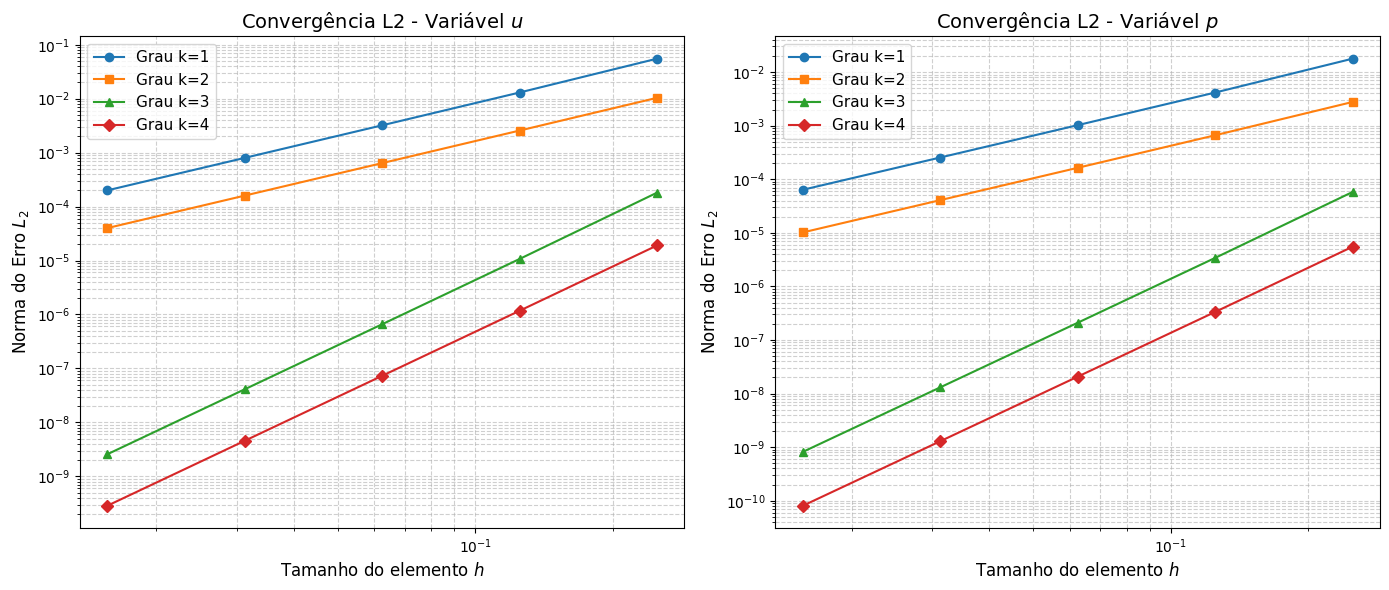

In [25]:
convergence_study_g()

In [26]:
# L = 1.0
# n_elem = 1024
# k = 4
# print("GLS comum:")
# nodes, elements, u_approx, p_approx = solve_fem_high_order(L, n_elem, k)
# print("GLS completo:")
# nodes, elements, u_approx, p_approx = solve_fem_high_order_f(L, n_elem, k)
# print("Sem nada:")
# nodes, elements, u_approx, p_approx = solve_fem_high_order_no_est(L, n_elem, k)
